<a href="https://colab.research.google.com/github/shivansh2310/The-Egg-Project/blob/main/Egg_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
#

In [2]:
egg_data = pd.read_csv("/content/necc_egg_prices_daily.csv")
egg_data

,date,year,month,day,market,category,price,price_filled,fill_method
0,2009-01-01,2009,1,1,Ahmedabad,NECC,204.0,204.0,observed
1,2009-01-01,2009,1,1,Ajmer,NECC,212.0,212.0,observed
2,2009-01-01,2009,1,1,Asansole,NECC,NaN,500.0,next_price
3,2009-01-01,2009,1,1,Barwala,NECC,NaN,168.0,next_price
4,2009-01-01,2009,1,1,Bengaluru (CC),NECC,195.0,195.0,observed
...,...,...,...,...,...,...,...,...,...
241675,2026-05-31,2026,5,31,Muzaffurpur (CC),PREVAILING,580.0,580.0,observed
241676,2026-05-31,2026,5,31,Nagpur,PREVAILING,600.0,600.0,observed
241677,2026-05-31,2026,5,31,Patna,PREVAILING,580.0,580.0,observed
241678,2026-05-31,2026,5,31,Ranchi (CC),PREVAILING,595.0,595.0,observed


### Data Overview
Let's start by getting a concise summary of the DataFrame using `info()` to see the data types and non-null values, and then display descriptive statistics of the numerical columns using `describe()`.

In [3]:
print(egg_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 241680 entries, 0 to 241679
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   date          241680 non-null  object 
 1   year          241680 non-null  int64  
 2   month         241680 non-null  int64  
 3   day           241680 non-null  int64  
 4   market        241680 non-null  object 
 5   category      241680 non-null  object 
 6   price         196859 non-null  float64
 7   price_filled  241680 non-null  float64
 8   fill_method   241680 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 16.6+ MB
None


In [4]:
display(egg_data.describe())

,year,month,day,price,price_filled
count,241680.000000,241680.000000,241680.000000,196859.000000,241680.000000
mean,2017.214308,6.439780,15.726572,388.111979,401.741958
std,5.030466,3.456087,8.798742,111.157820,109.112713
min,2009.000000,1.000000,1.000000,100.000000,100.000000
25%,2013.000000,3.000000,8.000000,305.000000,315.000000
50%,2017.000000,6.000000,16.000000,380.000000,405.000000
75%,2022.000000,9.000000,23.000000,466.000000,490.000000
max,2026.000000,12.000000,31.000000,890.000000,890.000000


### Data Cleaning and Unique Value Check
First, let's convert the 'date' column to datetime objects. Then, we will check the unique values and their counts for key categorical columns to understand the distinct entries within them.

In [5]:
egg_data['date'] = pd.to_datetime(egg_data['date'])
print(f"Date column converted to datetime. New dtype: {egg_data['date'].dtype}")

Date column converted to datetime. New dtype: datetime64[ns]


In [6]:
for column in ['market', 'category', 'fill_method']:
    print(f"\nUnique values in '{column}':")
    print(egg_data[column].value_counts())


Unique values in 'market':
market
Jabalpur            12720
Ajmer                6360
Asansole             6360
Barwala              6360
Ahmedabad            6360
Bengaluru (CC)       6360
Brahmapur (OD)       6360
Chennai (CC)         6360
Burdwan (CC)         6360
Delhi (CC)           6360
E.Godavari           6360
Hospet               6360
Chittoor             6360
Hyderabad            6360
Kolkata (WB)         6360
Ludhiana             6360
Midnapur (KOL)       6360
Mumbai (CC)          6360
Mysuru               6360
Namakkal             6360
Pune                 6360
Raipur               6360
Surat                6360
Vijayawada           6360
Vizag                6360
W.Godavari           6360
Warangal             6360
Allahabad (CC)       6360
Bhopal               6360
Indore (CC)          6360
Kanpur (CC)          6360
Luknow (CC)          6360
Muzaffurpur (CC)     6360
Nagpur               6360
Patna                6360
Ranchi  (CC)         6360
Varanasi (CC)        6360
Nam

### Price Distribution Analysis
Let's visualize the distribution of the `price_filled` column to understand its characteristics using a histogram and a box plot.

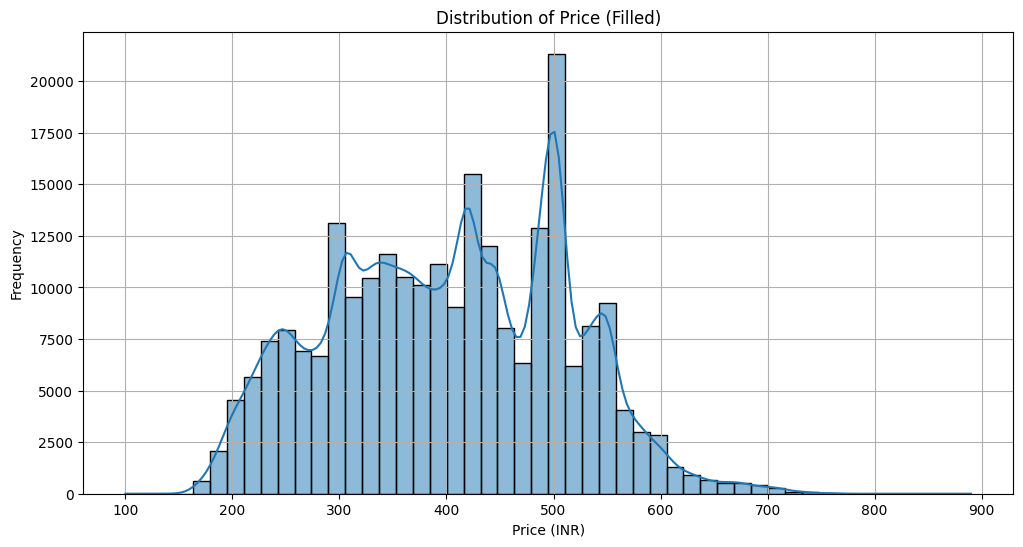

In [7]:
plt.figure(figsize=(12, 6))
sns.histplot(egg_data['price_filled'], kde=True, bins=50)
plt.title('Distribution of Price (Filled)')
plt.xlabel('Price (INR)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

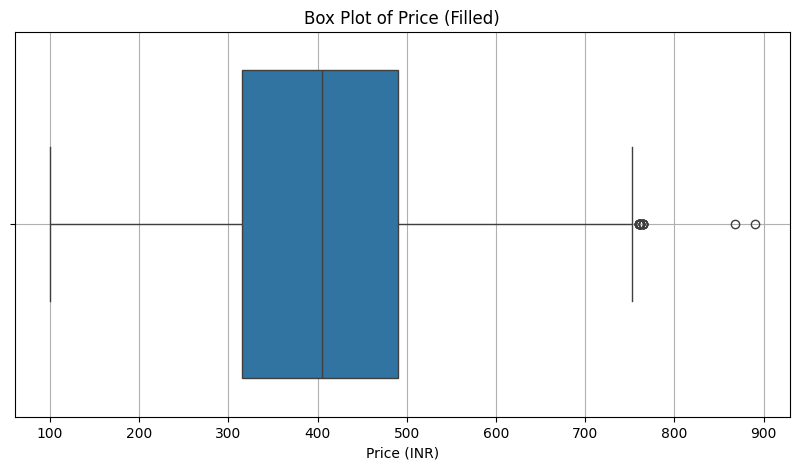

In [8]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=egg_data['price_filled'])
plt.title('Box Plot of Price (Filled)')
plt.xlabel('Price (INR)')
plt.grid(True)
plt.show()

### Price Trends Over Time
Let's analyze the average daily egg price over the entire period to observe any overall trends or seasonality.

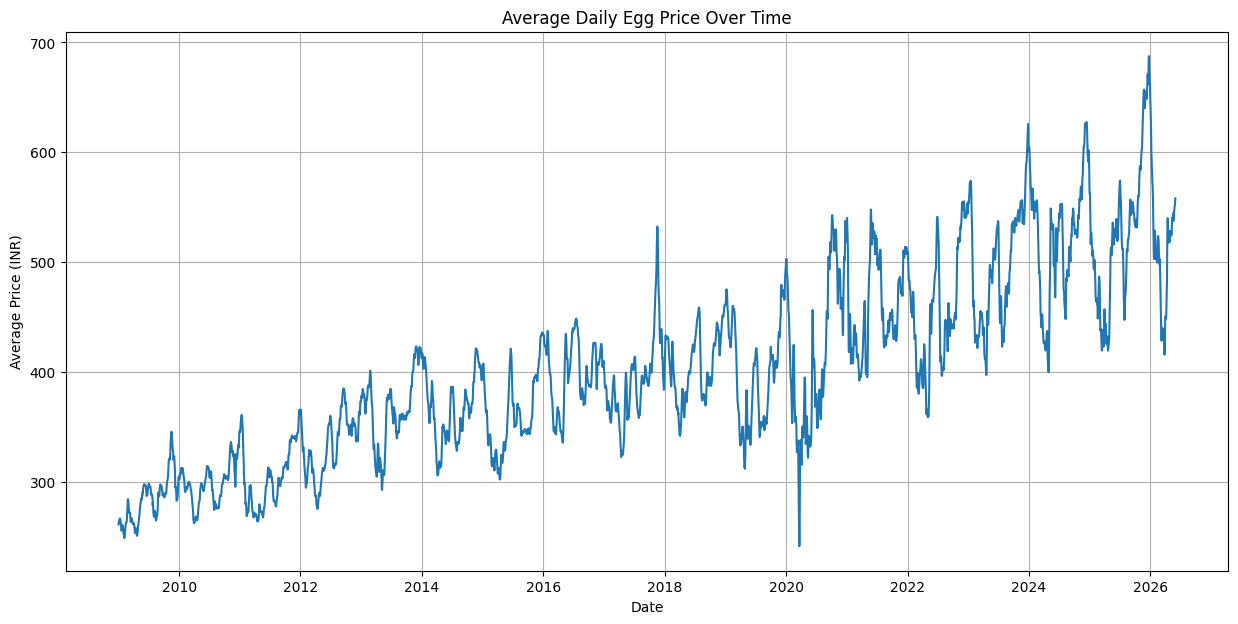

In [9]:
daily_avg_price = egg_data.groupby('date')['price_filled'].mean().reset_index()

plt.figure(figsize=(15, 7))
sns.lineplot(data=daily_avg_price, x='date', y='price_filled')
plt.title('Average Daily Egg Price Over Time')
plt.xlabel('Date')
plt.ylabel('Average Price (INR)')
plt.grid(True)
plt.show()

### Reshaping Data: Market Prices as Columns
To facilitate cross-market price analysis, let's pivot the `egg_data` DataFrame. The 'date' will serve as the index, 'market' names will become new columns, and 'price_filled' will be the values within these new columns. This will give us a wide-format DataFrame where we can compare daily prices across all markets directly.

In [13]:
market_prices_df = egg_data.pivot_table(index='date', columns='market', values='price_filled')
display(market_prices_df.head(5))

market,Ahmedabad,Ajmer,Allahabad (CC),Asansole,Barwala,Bengaluru (CC),Bhopal,Brahmapur (OD),Burdwan (CC),Chennai (CC),...,Patna,Pune,Raipur,Ranchi (CC),Surat,Varanasi (CC),Vijayawada,Vizag,W.Godavari,Warangal
date,,,,,,,,,,,,,,,,,,,,,
2009-01-01,204.0,212.0,198.0,500.0,168.0,195.0,180.0,305.0,504.0,203.0,...,486.0,168.0,180.0,500.0,445.0,212.0,184.0,200.0,184.0,187.0
2009-01-02,206.0,212.0,198.0,500.0,168.0,195.0,180.0,305.0,504.0,203.0,...,486.0,168.0,180.0,500.0,445.0,212.0,186.0,200.0,186.0,189.0
2009-01-03,208.0,216.0,198.0,500.0,168.0,197.0,180.0,305.0,504.0,203.0,...,486.0,168.0,180.0,500.0,445.0,214.0,188.0,200.0,188.0,191.0
2009-01-04,210.0,230.0,198.0,500.0,168.0,198.0,180.0,305.0,504.0,203.0,...,486.0,168.0,180.0,500.0,445.0,214.0,190.0,202.0,190.0,193.0
2009-01-05,210.0,230.0,198.0,500.0,168.0,198.0,180.0,305.0,504.0,203.0,...,486.0,168.0,180.0,500.0,445.0,214.0,190.0,202.0,190.0,193.0


In [14]:
market_prices_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6360 entries, 2009-01-01 to 2026-05-31
Data columns (total 37 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Ahmedabad         6360 non-null   float64
 1   Ajmer             6360 non-null   float64
 2   Allahabad (CC)    6360 non-null   float64
 3   Asansole          6360 non-null   float64
 4   Barwala           6360 non-null   float64
 5   Bengaluru (CC)    6360 non-null   float64
 6   Bhopal            6360 non-null   float64
 7   Brahmapur (OD)    6360 non-null   float64
 8   Burdwan (CC)      6360 non-null   float64
 9   Chennai (CC)      6360 non-null   float64
 10  Chittoor          6360 non-null   float64
 11  Delhi (CC)        6360 non-null   float64
 12  E.Godavari        6360 non-null   float64
 13  Hospet            6360 non-null   float64
 14  Hyderabad         6360 non-null   float64
 15  Indore (CC)       6360 non-null   float64
 16  Jabalpur          6360 n

In [15]:
market_prices_df.describe()

market,Ahmedabad,Ajmer,Allahabad (CC),Asansole,Barwala,Bengaluru (CC),Bhopal,Brahmapur (OD),Burdwan (CC),Chennai (CC),...,Patna,Pune,Raipur,Ranchi (CC),Surat,Varanasi (CC),Vijayawada,Vizag,W.Godavari,Warangal
count,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000,...,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000,6360.000000
mean,392.353066,358.508569,390.002123,464.097720,356.826494,387.799764,376.942296,374.058648,466.751101,399.209119,...,488.183648,401.103066,376.075629,499.266903,464.983019,402.373035,366.394811,375.890252,364.363836,361.515330
std,108.842006,104.746690,112.329721,45.016986,104.150581,111.555654,105.065137,96.804501,46.576188,111.529913,...,61.189324,115.019521,103.231167,57.471091,59.292455,112.042570,107.692659,103.078440,105.486337,102.150952
min,186.000000,168.000000,186.000000,275.000000,165.000000,170.000000,175.000000,200.000000,275.000000,178.000000,...,257.000000,165.000000,173.000000,286.000000,260.000000,193.000000,165.000000,180.000000,165.000000,169.000000
25%,312.000000,280.000000,305.000000,420.000000,280.000000,304.000000,302.000000,305.000000,420.000000,315.000000,...,486.000000,312.000000,300.000000,500.000000,445.000000,319.000000,285.000000,300.000000,285.000000,287.000000
50%,385.000000,345.000000,378.000000,500.000000,350.000000,375.000000,370.000000,305.000000,504.000000,390.000000,...,486.000000,393.000000,370.000000,500.000000,445.000000,395.000000,358.000000,368.000000,357.000000,353.000000
75%,464.000000,425.000000,467.000000,500.000000,421.000000,460.000000,445.000000,455.000000,504.000000,475.000000,...,486.000000,478.250000,445.000000,500.000000,470.000000,477.000000,440.000000,445.000000,437.000000,423.000000
max,710.000000,708.000000,738.000000,525.000000,703.000000,705.000000,710.000000,720.000000,575.000000,710.000000,...,765.000000,740.000000,701.000000,762.000000,715.000000,750.000000,720.000000,702.000000,695.000000,677.000000


### Price Trends for Specific Markets
Let's compare the price trends for 'Delhi (CC)' and 'Mumbai (CC)' to see how these major markets behave over time.

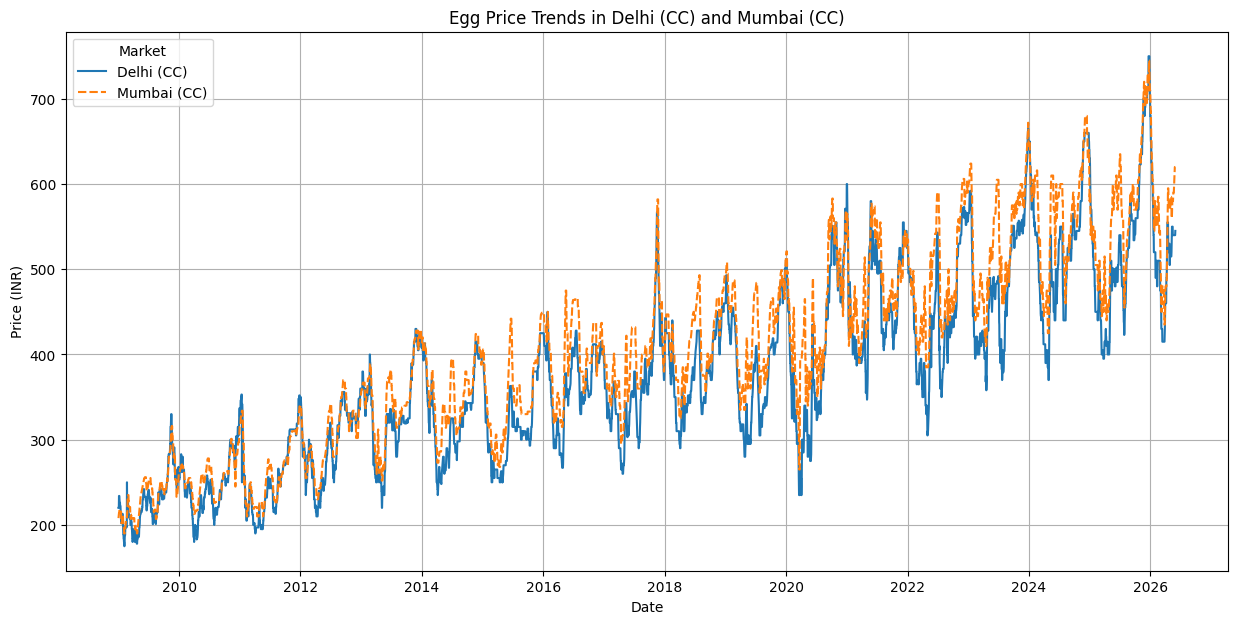

In [16]:
plt.figure(figsize=(15, 7))
sns.lineplot(data=market_prices_df[['Delhi (CC)', 'Mumbai (CC)']])
plt.title('Egg Price Trends in Delhi (CC) and Mumbai (CC)')
plt.xlabel('Date')
plt.ylabel('Price (INR)')
plt.legend(title='Market')
plt.grid(True)
plt.show()

### Correlation Matrix of Market Prices
To understand how prices in different markets move together, let's compute the correlation matrix. A high positive correlation indicates that prices in those markets tend to increase and decrease together.

In [17]:
correlation_matrix = market_prices_df.corr()
display(correlation_matrix.head())

market,Ahmedabad,Ajmer,Allahabad (CC),Asansole,Barwala,Bengaluru (CC),Bhopal,Brahmapur (OD),Burdwan (CC),Chennai (CC),...,Patna,Pune,Raipur,Ranchi (CC),Surat,Varanasi (CC),Vijayawada,Vizag,W.Godavari,Warangal
market,,,,,,,,,,,,,,,,,,,,,
Ahmedabad,1.000000,0.979758,0.989094,-0.613362,0.979972,0.983977,0.989485,0.844977,-0.623549,0.977482,...,0.471362,0.991153,0.988765,0.431585,0.699448,0.988886,0.991306,0.988146,0.991835,0.991077
Ajmer,0.979758,1.000000,0.989744,-0.566595,0.995253,0.953520,0.986036,0.849823,-0.576604,0.942325,...,0.549434,0.968443,0.977259,0.506938,0.733314,0.989112,0.976247,0.968661,0.977363,0.973481
Allahabad (CC),0.989094,0.989744,1.000000,-0.598376,0.989797,0.973389,0.990824,0.858435,-0.609270,0.965277,...,0.518919,0.983750,0.986342,0.476065,0.722370,0.993810,0.987067,0.982075,0.987641,0.983825
Asansole,-0.613362,-0.566595,-0.598376,1.000000,-0.561972,-0.625809,-0.571430,-0.719217,0.994687,-0.635103,...,0.143407,-0.622175,-0.601345,0.197260,-0.196551,-0.599327,-0.626243,-0.636922,-0.619224,-0.596778
Barwala,0.979972,0.995253,0.989797,-0.561972,1.000000,0.953080,0.985351,0.838940,-0.571702,0.941831,...,0.542655,0.968532,0.977960,0.500881,0.720310,0.992320,0.977381,0.969242,0.978756,0.973772


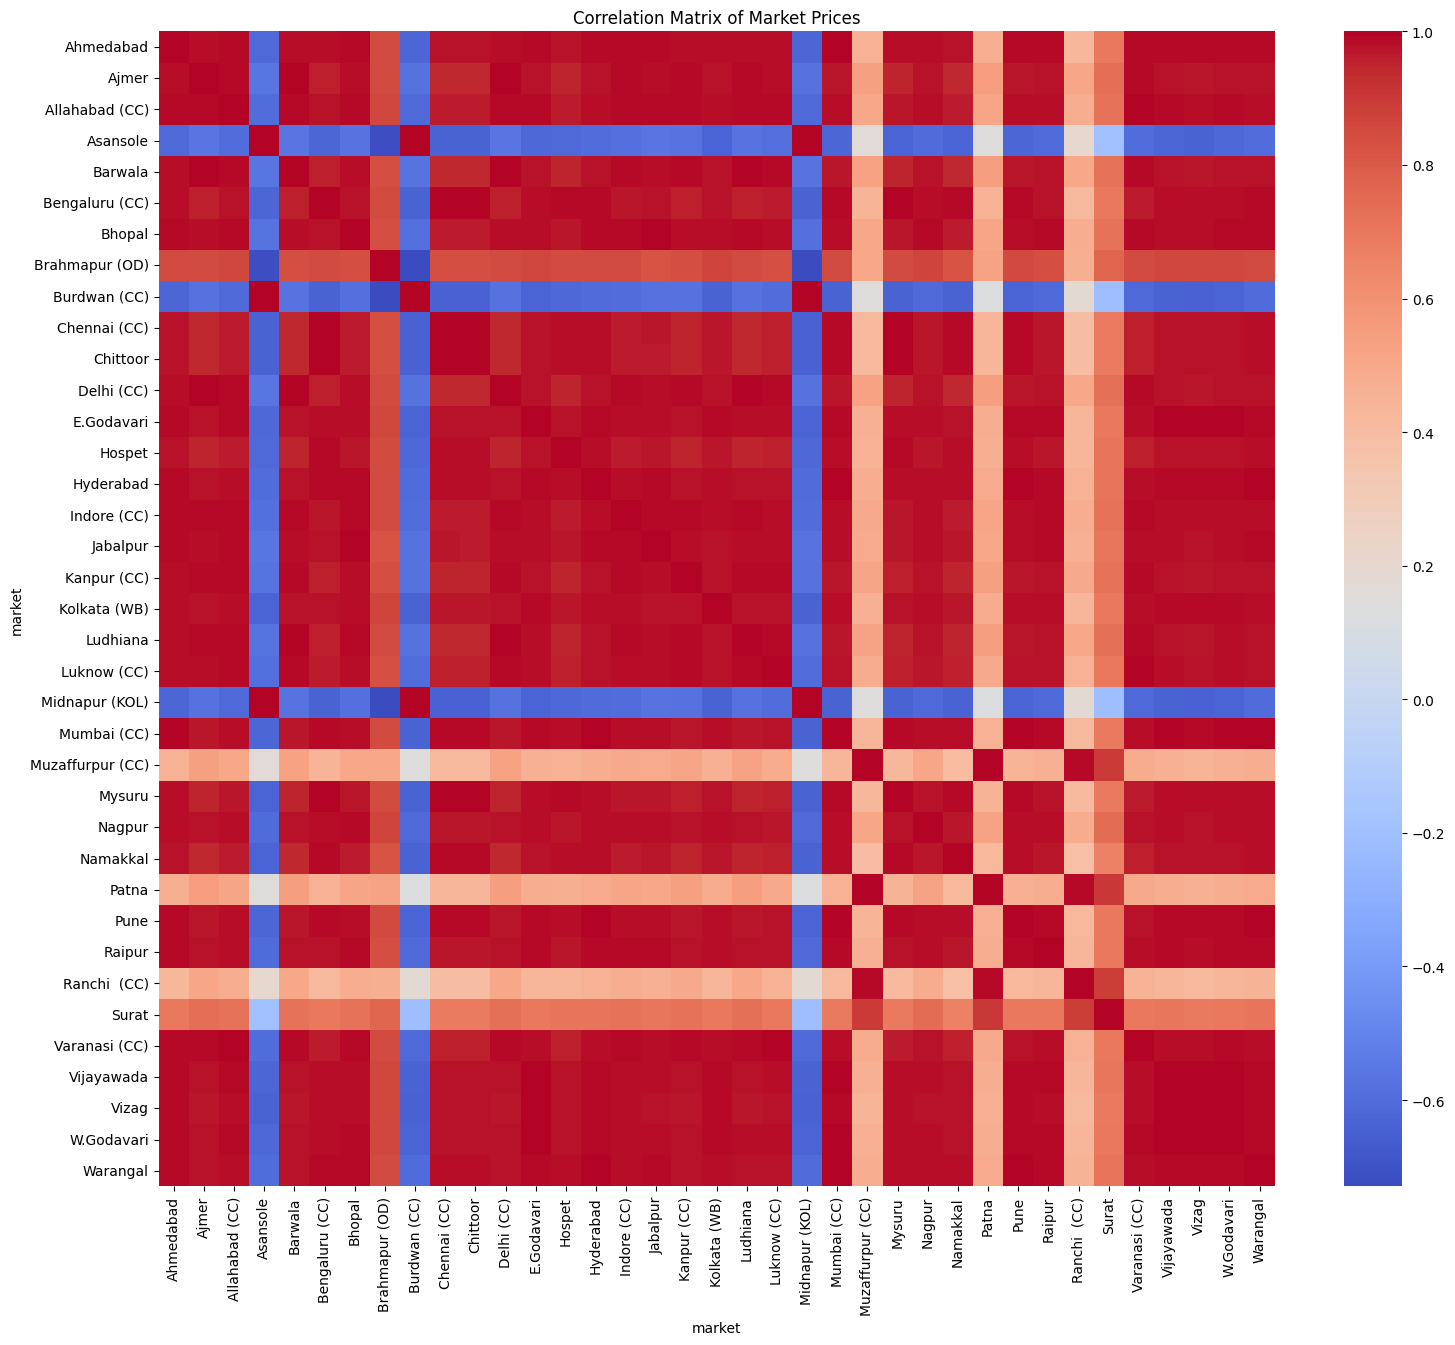

In [18]:
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Market Prices')
plt.show()

In [19]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist

# Calculate the distance matrix from the correlation matrix
# Using 1 - correlation as a distance measure
distance_matrix = 1 - correlation_matrix

# Perform hierarchical clustering
# 'ward' method minimizes the variance within each cluster
linked = linkage(distance_matrix, method='ward')

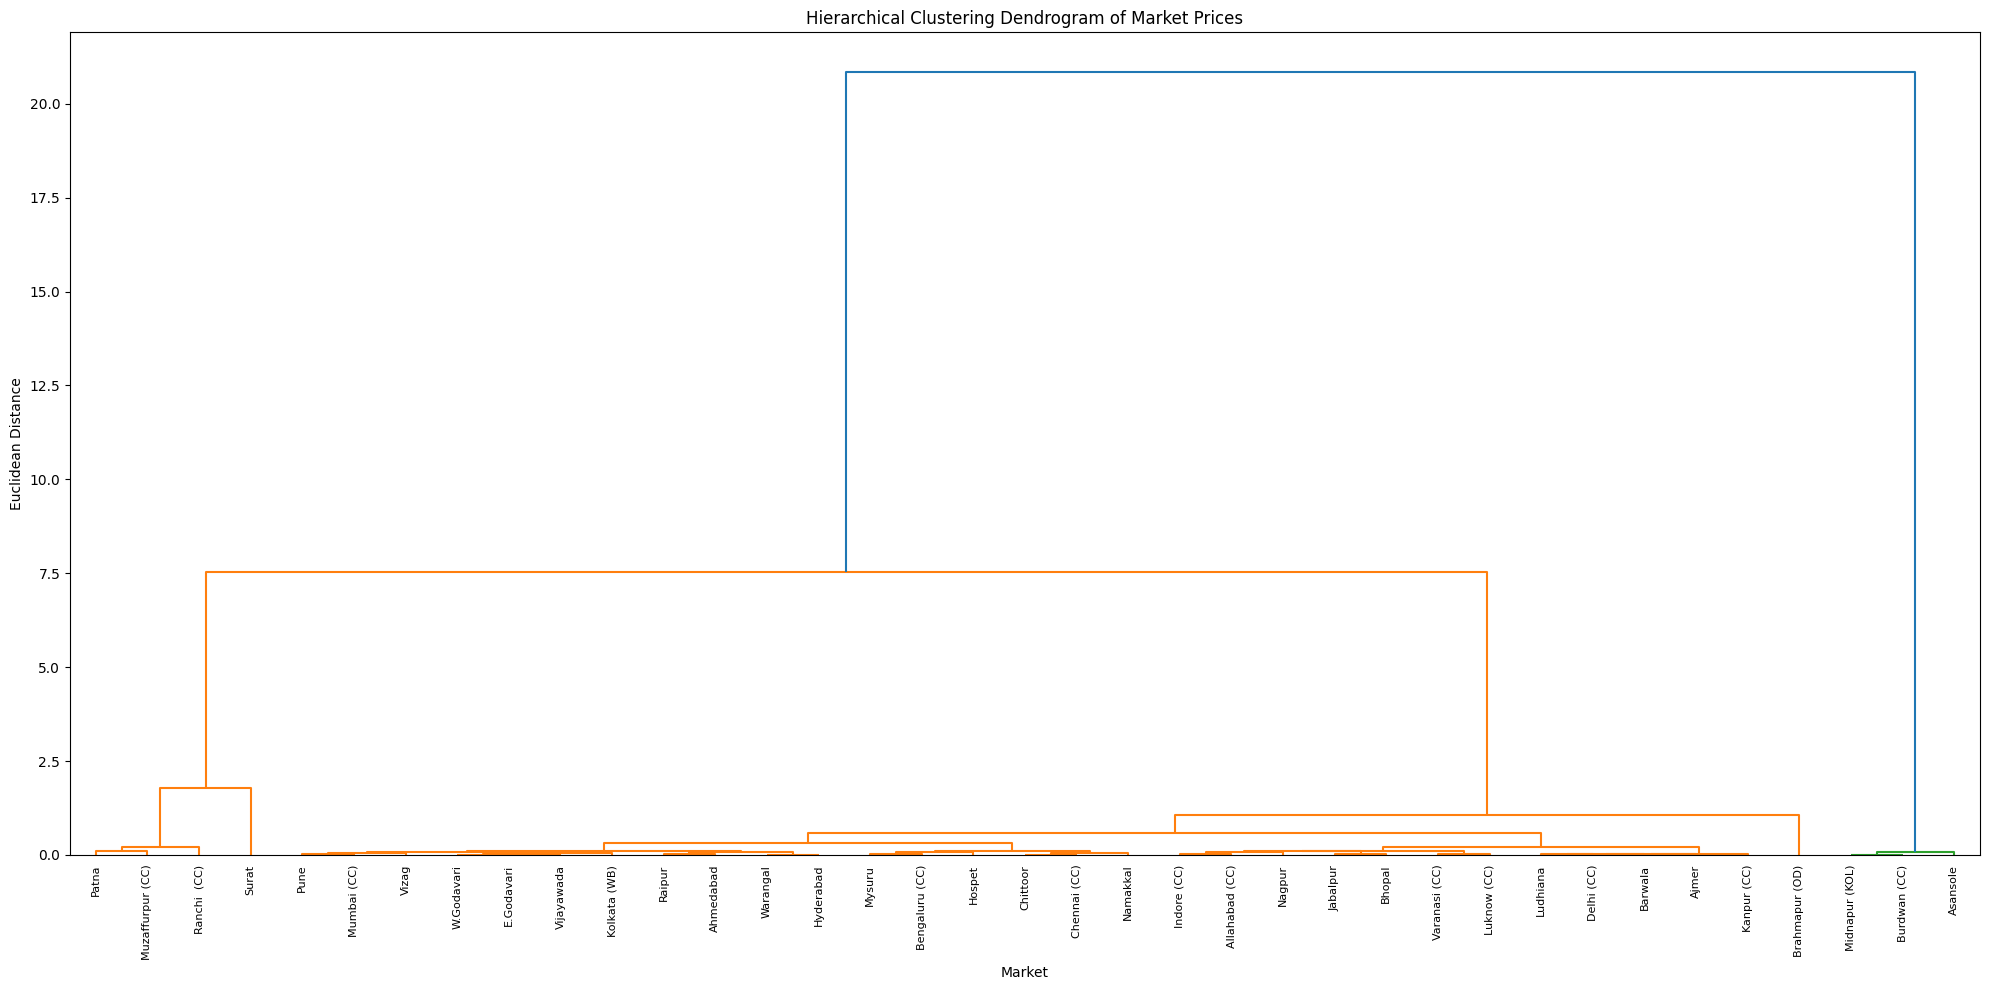

In [20]:
plt.figure(figsize=(20, 10))
dendrogram(
    linked,
    orientation='top',
    labels=correlation_matrix.columns.tolist(), # Use market names as labels
    distance_sort='descending',
    show_leaf_counts=True
)
plt.title('Hierarchical Clustering Dendrogram of Market Prices')
plt.xlabel('Market')
plt.ylabel('Euclidean Distance')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()